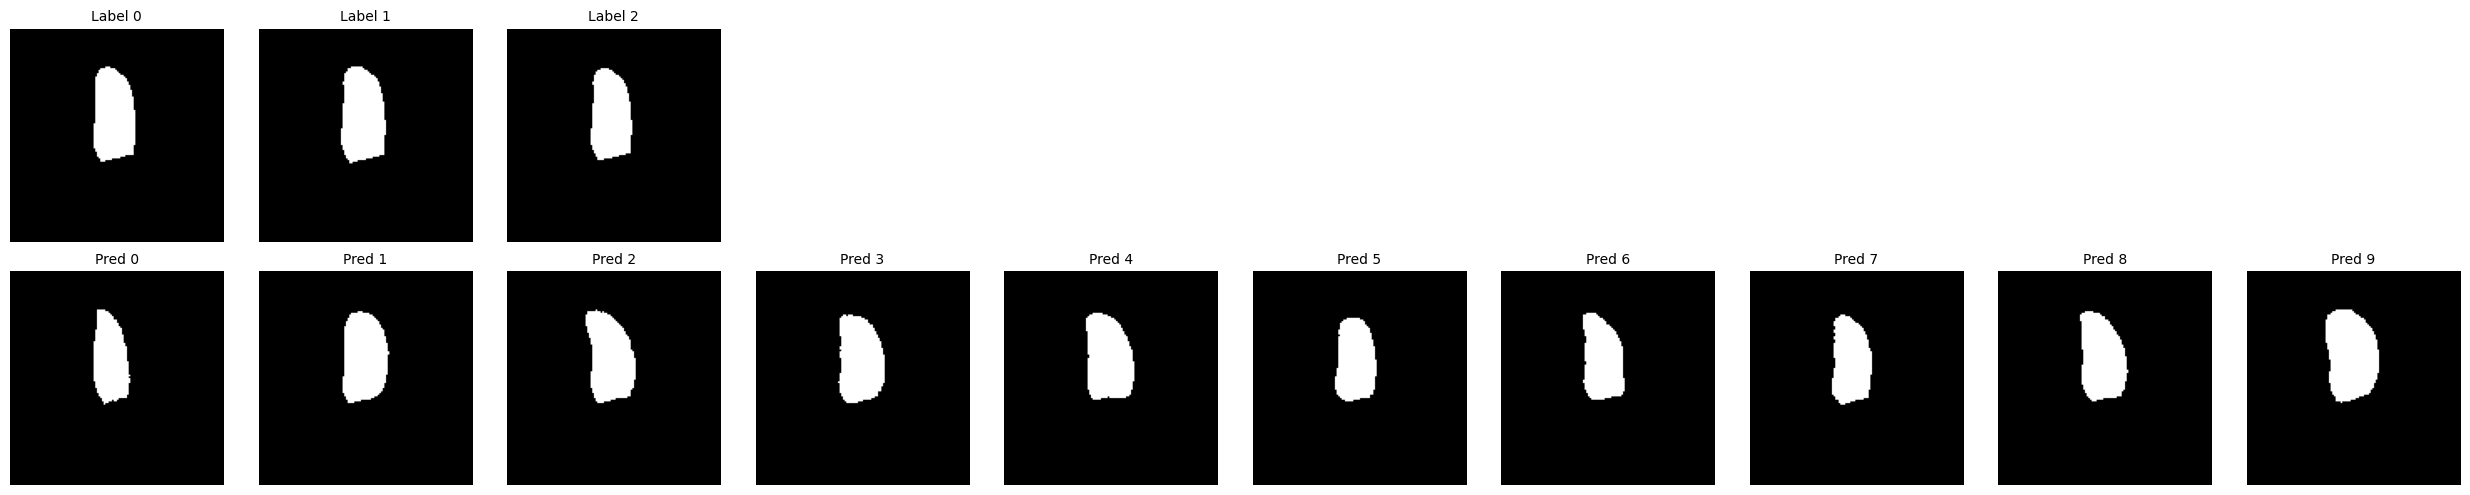

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 加载数据
labels = np.load("stage1_image/labels.npy")   # shape: (3, H, W)
preds = np.load("stage1_image/preds.npy")     # shape: (10, H, W)

num_labels = labels.shape[0]   # 3
num_preds = preds.shape[0]     # 10

# 创建子图：2 行，列数为 max(3, 10) = 10，不足的留空
n_cols = max(num_labels, num_preds)
fig, axes = plt.subplots(2, n_cols, figsize=(2.5 * n_cols, 5))

# 如果只有一列，axes 不是二维数组，需要统一处理
if n_cols == 1:
    axes = axes[:, np.newaxis]

# 第一行：labels（黑白）
for i in range(n_cols):
    axes[0, i].axis('off')
    if i < num_labels:
        axes[0, i].imshow(labels[i], cmap='gray')
        axes[0, i].set_title(f'Label {i}', fontsize=10)
    else:
        axes[0, i].set_visible(False)  # 超出 label 数量的子图隐藏

# 第二行：predictions（黑白）
for i in range(n_cols):
    axes[1, i].axis('off')
    if i < num_preds:
        axes[1, i].imshow(preds[i], cmap='gray')
        axes[1, i].set_title(f'Pred {i}', fontsize=10)
    else:
        axes[1, i].set_visible(False)  # 超出 pred 数量的子图隐藏

plt.tight_layout()
plt.savefig("stage1_image/labels_vs_preds_blackwhite.png", dpi=200, bbox_inches='tight')
plt.show()

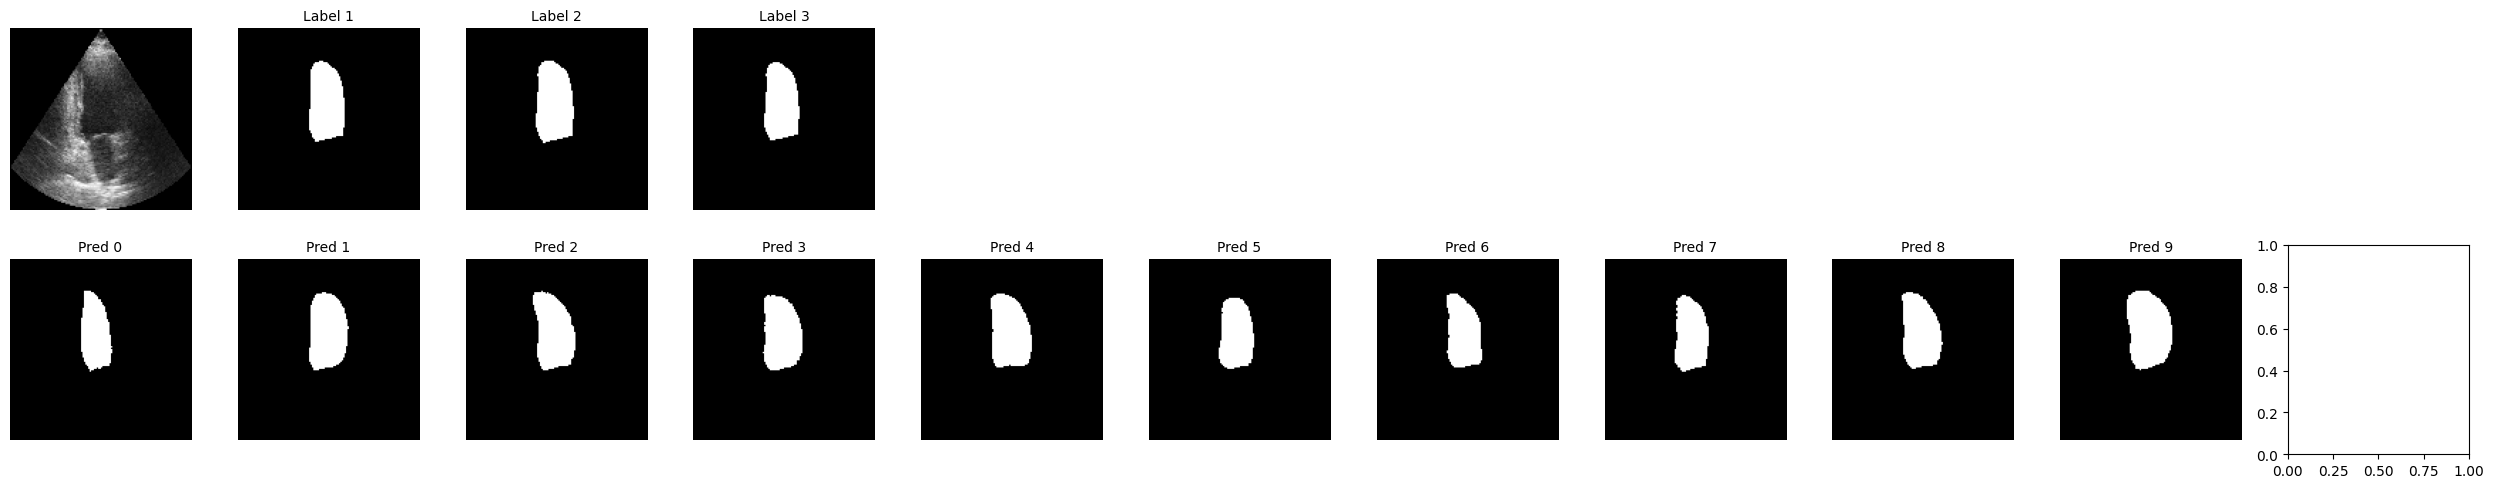

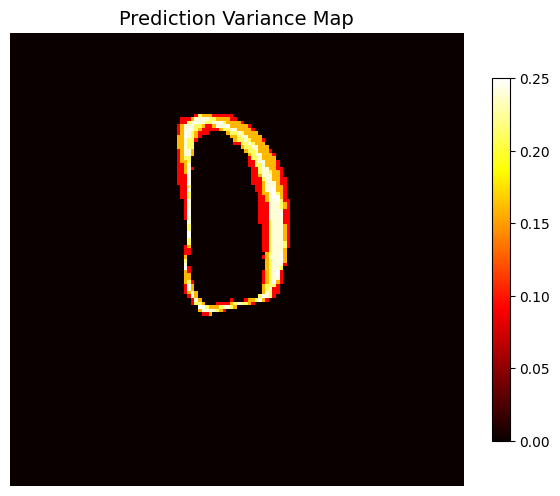

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 加载数据
image = np.load("stage1_image/image.npy")
labels = np.load("stage1_image/labels.npy")   # shape: (3, H, W)
preds = np.load("stage1_image/preds.npy")     # shape: (10, H, W)

num_labels = labels.shape[0]   # 3
num_preds = preds.shape[0]     # 10

# 创建子图：2 行，列数为 max(3, 10) = 10，不足的留空
n_cols = max(num_labels+1, num_preds)
fig, axes = plt.subplots(2, n_cols+1, figsize=(2.5 * n_cols, 5))

# 如果只有一列，axes 不是二维数组，需要统一处理
if n_cols == 1:
    axes = axes[:, np.newaxis]

# 第一行：labels（黑白）
for i in range(n_cols+1):
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].imshow(image, cmap='gray')
    elif 0< i < num_labels+1:
        axes[0, i].imshow(labels[i-1], cmap='gray')
        axes[0, i].set_title(f'Label {i}', fontsize=10)
    else:
        axes[0, i].set_visible(False)  # 超出 label 数量的子图隐藏

# 第二行：predictions（黑白）
for i in range(n_cols):
    axes[1, i].axis('off')
    if i < num_preds:
        axes[1, i].imshow(preds[i], cmap='gray')
        axes[1, i].set_title(f'Pred {i}', fontsize=10)
    else:
        axes[1, i].set_visible(False)  # 超出 pred 数量的子图隐藏

plt.tight_layout()
plt.savefig("stage1_image/labels_vs_preds_blackwhite.png", dpi=200, bbox_inches='tight')
plt.show()

# ================================
# 新增：计算 preds 的方差图并可视化
# ================================
variance_map = np.var(preds, axis=0)  # shape: (H, W)

plt.figure(figsize=(6, 5))
plt.imshow(variance_map, cmap='hot')  # 'hot' 热力图更直观显示高方差区域
plt.axis('off')
plt.title('Prediction Variance Map', fontsize=14)
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.savefig("stage1_image/pred_variance_map.png", dpi=200, bbox_inches='tight')
plt.show()

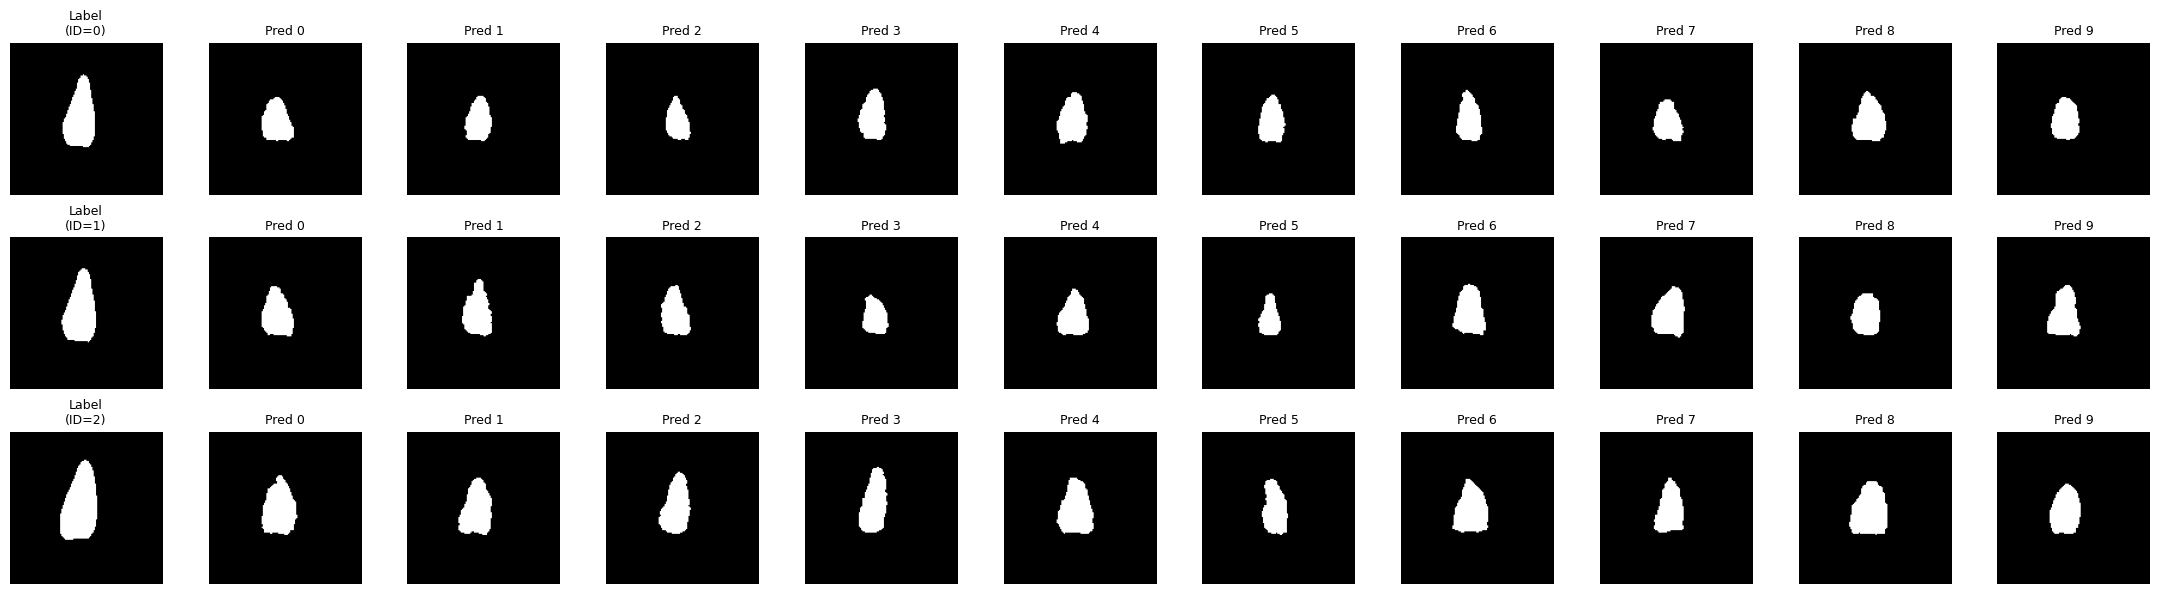

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 配置
ids = [0, 1, 2]  # 3 个 ID
n_pred = 10      # 预测数量
n_cols = 1 + n_pred  # 1 label + 10 predictions = 11 列
n_rows = len(ids)    # 3 行

# 创建大图
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 6))  # 宽度 22 ≈ 2*11

# 统一 cmap（用于类别图）
cmap = 'gray'  # 支持最多20类；若二分类可用 'gray'

for row, id_val in enumerate(ids):
    # --- 加载 label ---
    label_path = f"stage2_image/label_{id_val}.npy"
    if os.path.exists(label_path):
        label = np.load(label_path)[0]  # shape: (H, W)
        axes[row, 0].imshow(label, cmap=cmap)
        axes[row, 0].set_title(f'Label\n(ID={id_val})', fontsize=9)
    else:
        axes[row, 0].text(0.5, 0.5, 'Label\nMissing', ha='center', va='center', fontsize=8)
    axes[row, 0].axis('off')

    # --- 加载 10 predictions ---
    pred_path = f"stage2_image/10_prediction_{id_val}.npy"
    if os.path.exists(pred_path):
        preds = np.load(pred_path)  # shape: (10, H, W)
        if preds.shape[0] != 10:
            print(f"Warning: {pred_path} has {preds.shape[0]} predictions, expected 10.")
        for i in range(min(n_pred, preds.shape[0])):
            axes[row, 1 + i].imshow(preds[i], cmap=cmap)
            axes[row, 1 + i].set_title(f'Pred {i}', fontsize=9)
            axes[row, 1 + i].axis('off')
        # 如果少于10个，隐藏多余列
        for i in range(preds.shape[0], n_pred):
            axes[row, 1 + i].axis('off')
    else:
        for i in range(n_pred):
            axes[row, 1 + i].text(0.5, 0.5, 'Pred\nMissing', ha='center', va='center', fontsize=8)
            axes[row, 1 + i].axis('off')

plt.tight_layout(pad=1.0)
plt.savefig("stage2_image/3x11_labels_and_10preds.png", dpi=200, bbox_inches='tight')
plt.show()

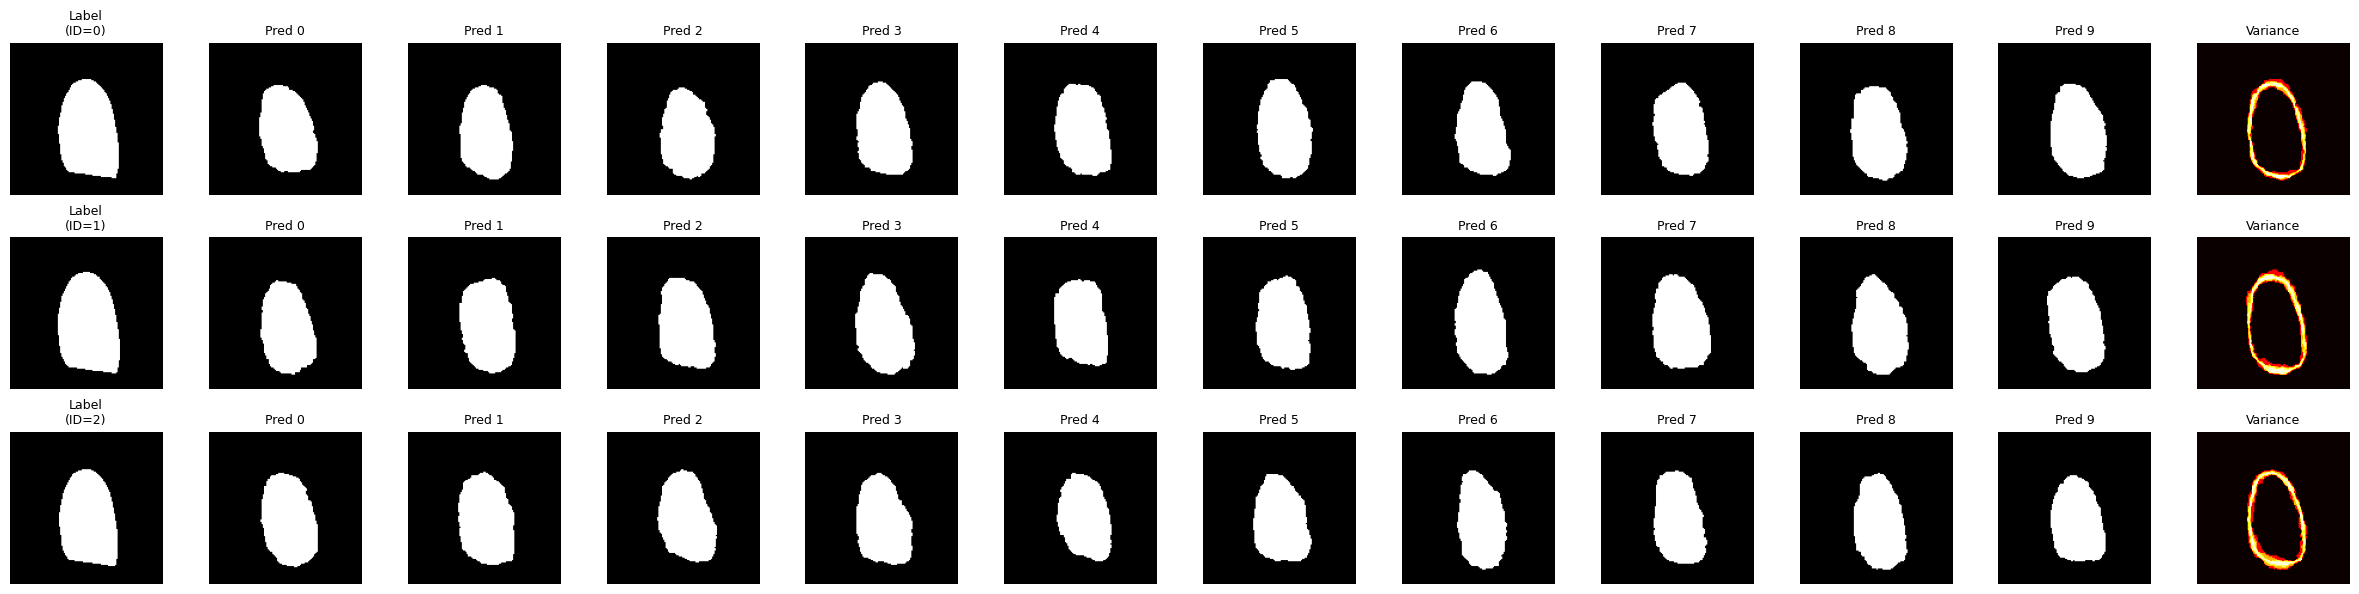

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 配置
ids = [0, 1, 2]           # 3 个 ID
n_pred = 10               # 预测数量
n_cols = 1 + n_pred + 1   # 1 label + 10 predictions + 1 variance = 12 列
n_rows = len(ids)         # 3 行

# 创建大图
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6))  # 宽度 ~2*12

# cmap for label/preds (categorical), and variance (continuous)
cmap_cat = 'gray'      # for label and predictions (discrete classes)
cmap_var = 'hot'        # for variance (continuous uncertainty)

for row, id_val in enumerate(ids):
    # --- 第 0 列：Label ---
    label_path = f"stage2_image/label_{id_val}.npy"
    if os.path.exists(label_path):
        label = np.load(label_path)[0]  # (H, W)
        axes[row, 0].imshow(label, cmap=cmap_cat)
        axes[row, 0].set_title(f'Label\n(ID={id_val})', fontsize=9)
    else:
        axes[row, 0].text(0.5, 0.5, 'Label\nMissing', ha='center', va='center', fontsize=8)
    axes[row, 0].axis('off')

    # --- 第 1~10 列：10 predictions ---
    pred_path = f"stage2_image/10_prediction_{id_val}.npy"
    if os.path.exists(pred_path):
        preds = np.load(pred_path)  # shape: (10, H, W)
        if preds.shape[0] != 10:
            print(f"Warning: {pred_path} has {preds.shape[0]} predictions, expected 10.")
        
        # 显示10个预测
        for i in range(min(n_pred, preds.shape[0])):
            axes[row, 1 + i].imshow(preds[i], cmap=cmap_cat)
            axes[row, 1 + i].set_title(f'Pred {i}', fontsize=9)
            axes[row, 1 + i].axis('off')
        # 隐藏多余列（如果 preds < 10）
        for i in range(preds.shape[0], n_pred):
            axes[row, 1 + i].axis('off')
    else:
        for i in range(n_pred):
            axes[row, 1 + i].text(0.5, 0.5, 'Pred\nMissing', ha='center', va='center', fontsize=8)
            axes[row, 1 + i].axis('off')

    # --- 第 11 列（最后一列）：Variance Map ---
    var_ax = axes[row, -1]
    if os.path.exists(pred_path) and 'preds' in locals():
        variance_map = np.var(preds, axis=0)  # shape: (H, W)
        im = var_ax.imshow(variance_map, cmap=cmap_var)
        var_ax.set_title('Variance', fontsize=9)
        var_ax.axis('off')
    else:
        var_ax.text(0.5, 0.5, 'Var\nMissing', ha='center', va='center', fontsize=8)
        var_ax.axis('off')

# 调整布局并保存
plt.tight_layout(pad=1.0)
plt.savefig("stage2_image/3x12_labels_preds_variance.png", dpi=200, bbox_inches='tight')
plt.show()

In [1]:
# 可视化中间过程

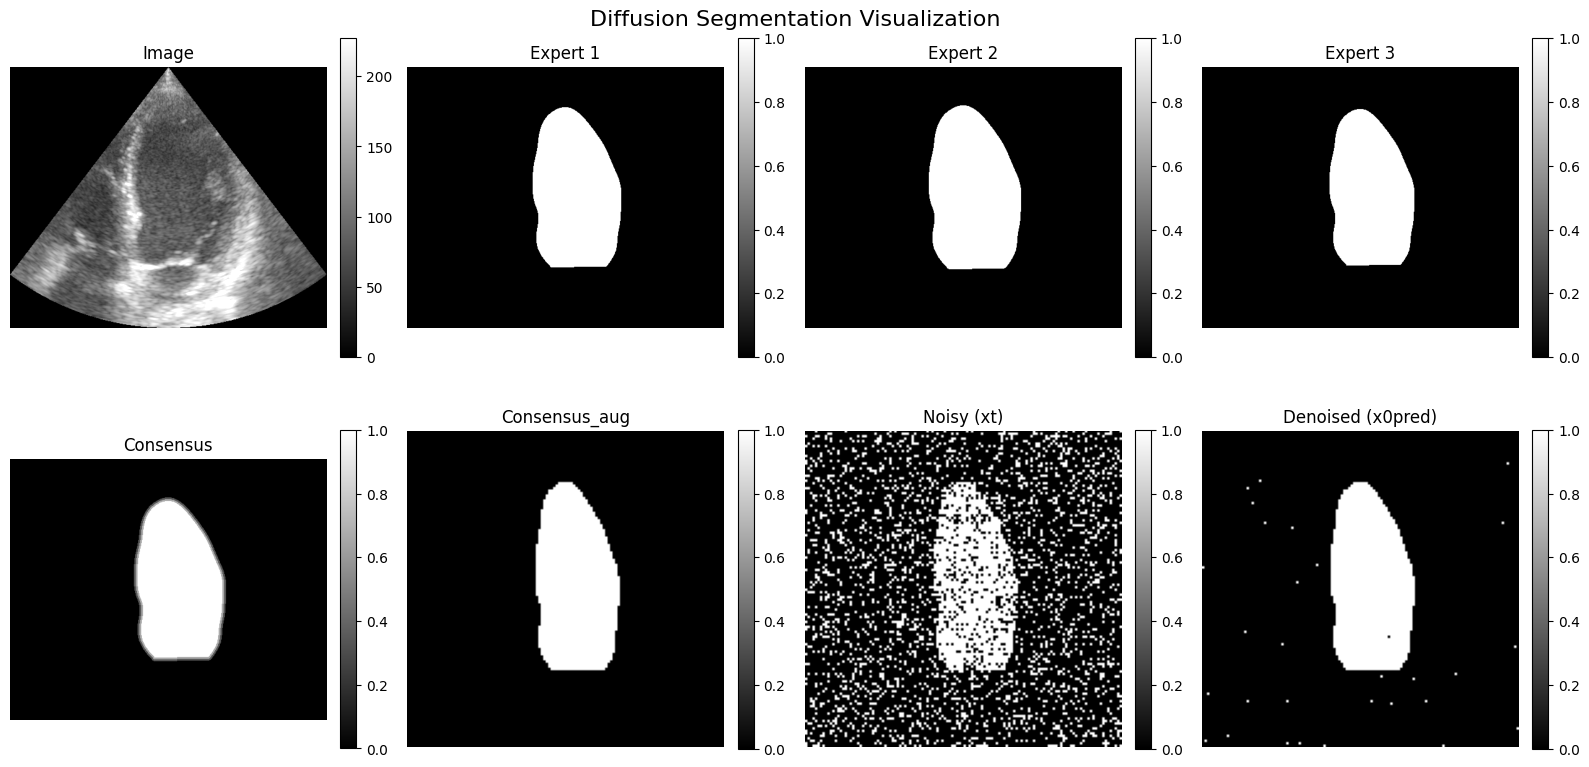

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 设置路径
viz_dir = "visual_debug"
files = {
    "Image": "image.npy",
    "Expert 1": "labels.npy",   # 第一个通道
    "Expert 2": "labels.npy",   # 第二个通道
    "Expert 3": "labels.npy",   # 第三个通道
    "Consensus": "consensus.npy",
    "Consensus_aug": "consensus_aug.npy",
    "Noisy (xt)": "xt.npy",
    "Denoised (x0pred)": "x0pred.npy"
}

# 创建子图布局
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

idx = 0

for title, fname in files.items():
    path = os.path.join(viz_dir, fname)
    if not os.path.exists(path):
        print(f"⚠️ 警告: 文件 {path} 不存在，跳过")
        continue

    data = np.load(path)

    # 处理 labels.npy 的多通道
    if fname == "labels.npy":
        # 取对应通道（第一个专家取 channel 0，第二个取 channel 1，第三个取 channel 2）
        if "Expert 1" in title:
            data = data[0]  # 取第 0 通道
        elif "Expert 2" in title:
            data = data[1]  # 取第 1 通道
        elif "Expert 3" in title:
            data = data[2]  # 取第 2 通道
    else:
        # 其余文件为单通道，可能有 batch 或 channel 维度
        if data.ndim == 3:  # [C, H, W]
            data = data[0]  # 取第一个通道
        elif data.ndim == 4:  # [B, C, H, W]
            data = data[0, 0]  # 取 batch 0, channel 0

    # 自动裁剪显示范围（增强对比度）
    vmin, vmax = np.percentile(data, [1, 99]) if np.any(data != 0) else (data.min(), data.max())

    ax = axes[idx]
    im = ax.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    idx += 1

# 删除多余的子图
for i in range(idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle("Diffusion Segmentation Visualization", fontsize=16)
plt.show()